In [1]:

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df.loc[:, 'salary_rate':'salary_hour_avg'].dropna(subset='salary_rate')

,salary_rate,salary_year_avg,salary_hour_avg
28,year,109500.0,NaN
43,hour,NaN,97.5
51,hour,NaN,72.5
77,year,140000.0,NaN
92,year,120000.0,NaN
...,...,...,...
785624,year,139216.0,NaN
785641,year,150000.0,NaN
785648,year,221875.0,NaN
785682,year,157500.0,NaN


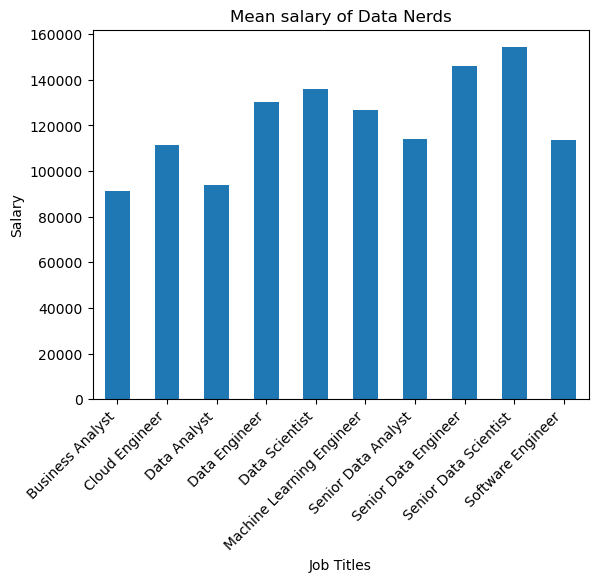

In [3]:
job_salary_mean = df.groupby('job_title_short')['salary_year_avg'].mean()
job_salary_mean.plot(x='job_title_short', y='salary_year_avg', kind = 'bar')
plt.xticks(rotation = 45, ha='right')
plt.xlabel('Job Titles')
plt.ylabel('Salary')
plt.title('Mean salary of Data Nerds')
plt.show()

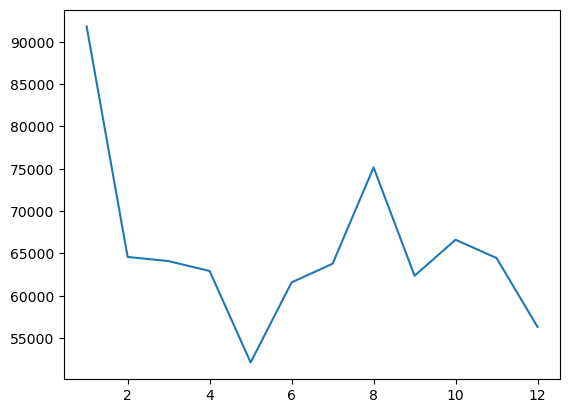

In [4]:
#job salary trend over time
import datetime as dt
df['job_posted_month'] = df.job_posted_date.dt.month
monthly_counts = df['job_posted_month'].value_counts()
monthly_counts = monthly_counts.sort_index()
plt.plot(monthly_counts.index, monthly_counts)


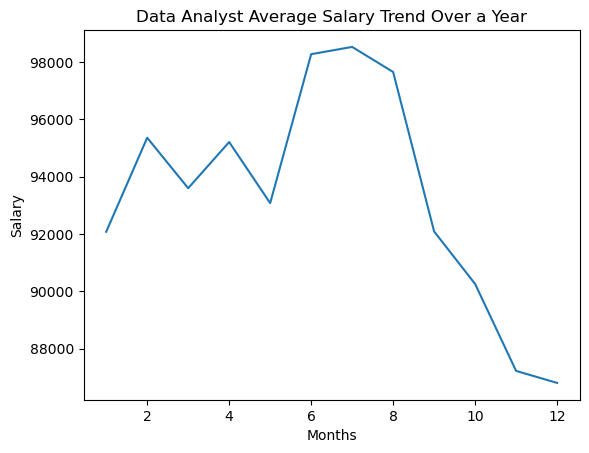

In [20]:
#job salary trend of data analysts over time
data_analyst_salary = df.loc[:,['job_title_short', 'salary_year_avg', 'job_posted_month']]
data_analyst_salary = data_analyst_salary.dropna(subset = 'salary_year_avg')
data_analyst_salary = data_analyst_salary[data_analyst_salary['job_title_short'] == 'Data Analyst']
data_analyst_salary.sort_values(by= 'job_posted_month')
data_analyst_salary = data_analyst_salary.groupby('job_posted_month')['salary_year_avg'].agg(['mean', 'median'])
data_analyst_salary
plt.plot(data_analyst_salary.index, data_analyst_salary['mean'])
plt.xlabel('Months')
plt.ylabel('Salary')
plt.title('Data Analyst Average Salary Trend Over a Year')
plt.show()
#significant increase during months 6-8
#significant drop during months 8-10
#needed more investigation